# Fama-French 三因子模型 — 学习笔记

本 notebook 是 [CAPM.ipynb](CAPM.ipynb) 的续篇：CAPM 用**单一**市场因子 β 解释收益；
Fama & French (1993) 发现，加入**规模(SMB)**与**价值(HML)**两个因子后，对横截面收益的解释力大幅提升。

**学习路径**：构建 2×3 分组组合 → 合成 SMB / HML / MKT 因子 → 因子表现检验 → 时序回归看 α 与解释力 → GRS 联合检验

---

## 一、理论公式 ↔ 代码变量

| 概念 | 公式 | 代码变量 |
|------|------|----------|
| 三因子回归 | $R_i-r_f=\alpha+\beta_{MKT}MKT+\beta_{SMB}SMB+\beta_{HML}HML+\varepsilon$ | `sm.OLS` |
| 市场因子 | $MKT=R_m-r_f$ | `ff['MKT']` |
| 规模因子 | $SMB=\overline{R_{small}}-\overline{R_{big}}$ | `ff['SMB']` |
| 价值因子 | $HML=\overline{R_{highBP}}-\overline{R_{lowBP}}$ | `ff['HML']` |
| 账面市值比 | $BP=B/M=1/PB$ | `bp` |
| 规模代理 | 总市值 | `mc` |

## 二、与 CAPM 的关系

CAPM 是三因子模型在 $\beta_{SMB}=\beta_{HML}=0$ 时的**特例**。若 FF3 的 α 比 CAPM 的 α 更接近 0、
$R^2$ 更高、GRS 联合检验更不显著，说明规模与价值因子确实捕捉了 CAPM 漏掉的系统性风险。

## 三、原文与参考资料

- **原始论文**：Fama, E. F., & French, K. R. (1993). *Common risk factors in the returns on stocks and bonds.* Journal of Financial Economics, 33(1), 3–56. [DOI:10.1016/0304-405X(93)90023-5](https://doi.org/10.1016/0304-405X(93)90023-5) ｜ [公开 PDF](https://www.bauer.uh.edu/rsusmel/phd/Fama-French_JFE93.pdf)
- **官方因子数据与构建口径**：[Kenneth R. French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)
- **GRS 联合检验**：Gibbons, M. R., Ross, S. A., & Shanken, J. (1989). *A test of the efficiency of a given portfolio.* Econometrica, 57(5), 1121–1152. [DOI:10.2307/1913625](https://doi.org/10.2307/1913625)

> **数据口径**：股票池=中证800 成分（期初快照，教学用固定池，真实研究应逐期调整）；
> 月频；规模/价值因子取上月末值（避免前视）；行情、市值、PB 均来自米筐 `rqdatac`；
> 无风险利率用年化 2% 常数（教学简化）。经典 FF 是年度 6 月底成形 + 年报账面价值，
> 这里简化为**月度调仓 + 点位 PB**，便于学习核心思想。

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 定位项目根目录（兼容 notebook 从不同目录启动）
PROJECT_ROOT = None
for _c in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '../..')]:
    _r = os.path.abspath(_c)
    if os.path.isdir(os.path.join(_r, 'my_utils')):
        PROJECT_ROOT = _r
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('未找到项目根目录（需包含 my_utils 文件夹）')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# RqData() 内部完成 rq.init(license)，之后可直接用模块级 rq.xxx 接口
from my_utils.rqdata import RqData
import rqdatac as rq

RqData()
print('米筐初始化完成')

米筐初始化完成


In [2]:
# ===================== Part 1：数据准备 =====================
start_date = '2021-01-01'
end_date = '2024-12-31'
rf_annual = 0.02            # 年化无风险利率（教学常数）
rf_monthly = rf_annual / 12

# 股票池：中证800 成分（期初快照）
universe = rq.index_components('000906.XSHG', date=start_date)
print(f'中证800 成分股数: {len(universe)}')

# --- 行情：日线后复权收盘价 -> 月收益 ---
px = rq.get_price(universe, start_date=start_date, end_date=end_date,
                  frequency='1d', fields='close', adjust_type='post')
close = px['close'].unstack('order_book_id')        # 行=日期, 列=股票
m_close = close.resample('M').last()                # 每月最后一个交易日收盘
m_ret = m_close.pct_change()                        # 月收益率

# --- 规模(市值) 与 价值(账面市值比 BP=1/PB)，取每月末值 ---
fac = rq.get_factor(universe, ['market_cap_3', 'pb_ratio_ttm'],
                    start_date=start_date, end_date=end_date)
mc = fac['market_cap_3'].unstack('order_book_id').resample('M').last()   # 总市值
pb = fac['pb_ratio_ttm'].unstack('order_book_id').resample('M').last()
bp = 1.0 / pb.where(pb > 0)                          # 账面市值比；PB<=0 视为缺失

# --- 市场组合：中证800 指数月收益 ---
idx = rq.get_price('000906.XSHG', start_date=start_date, end_date=end_date,
                   frequency='1d', fields='close')
idx_close = idx['close'].droplevel('order_book_id')
idx_m = idx_close.resample('M').last().pct_change()  # 指数月收益

print(f'月份数: {m_ret.shape[0]}, 股票数: {m_ret.shape[1]}')
print(f'样本区间: {m_ret.index.min():%Y-%m} ~ {m_ret.index.max():%Y-%m}')
m_ret.iloc[:3, :4]

中证800 成分股数: 800


月份数: 48, 股票数: 800
样本区间: 2021-01 ~ 2024-12


order_book_id,002271.XSHE,002311.XSHE,600291.XSHG,600161.XSHG
date,,,,
2021-01-31,NaN,NaN,NaN,NaN
2021-02-28,-0.02618557,0.20802310,0.02654867,-0.08857143
2021-03-31,0.08320982,-0.01886792,-0.13218391,-0.06925050


In [3]:
# ===================== Part 2：2×3 分组构建 SMB / HML =====================
# 经典 Fama-French 做法：
#   Size 维度按市值中位数分 2 组（S 小盘 / B 大盘）
#   Value 维度按 BP 的 30%/70% 分位分 3 组（L 低 / M 中 / H 高）
#   交叉得到 6 个组合：SL SM SH BL BM BH，组内按市值加权
# 关键防前视：第 t 月的组合收益，用第 t-1 月末观测到的 size/bp 分组

# 对齐三张表的股票与月份
common = m_ret.columns.intersection(mc.columns).intersection(bp.columns)
m_ret_a, mc_a, bp_a = m_ret[common], mc[common], bp[common]
months = m_ret_a.index

records = []
for i in range(1, len(months)):
    t, t_prev = months[i], months[i - 1]
    size = mc_a.loc[t_prev]      # 上月末市值（分组依据 + 加权权重）
    val = bp_a.loc[t_prev]       # 上月末账面市值比
    ret = m_ret_a.loc[t]         # 本月收益
    mask = size.notna() & val.notna() & ret.notna() & (size > 0)
    size, val, ret = size[mask], val[mask], ret[mask]
    if len(size) < 30:
        continue

    big = size >= size.median()                       # 大盘 = True
    q30, q70 = val.quantile(0.3), val.quantile(0.7)
    low, high = val <= q30, val >= q70
    mid = ~low & ~high

    def vw(sel):
        """组内市值加权收益；空组返回 NaN"""
        if sel.sum() == 0:
            return np.nan
        w = size[sel]
        return float((ret[sel] * w).sum() / w.sum())

    SL, SM, SH = vw(~big & low), vw(~big & mid), vw(~big & high)
    BL, BM, BH = vw(big & low), vw(big & mid), vw(big & high)
    smb = (SL + SM + SH) / 3 - (BL + BM + BH) / 3      # 小盘 - 大盘
    hml = (SH + BH) / 2 - (SL + BL) / 2                # 高BP - 低BP
    records.append(dict(month=t, SMB=smb, HML=hml,
                        SL=SL, SM=SM, SH=SH, BL=BL, BM=BM, BH=BH))

ff = pd.DataFrame(records).set_index('month')
ff['MKT'] = idx_m.reindex(ff.index) - rf_monthly      # 市场超额收益
ff = ff.dropna(subset=['SMB', 'HML', 'MKT'])
print(f'有效月份数: {len(ff)}')
ff[['MKT', 'SMB', 'HML']].head()

有效月份数: 47


,MKT,SMB,HML
month,,,
2021-02-28,-0.00325590,0.02932205,0.07598413
2021-03-31,-0.04765652,0.04841085,0.08331338
2021-04-30,0.01822046,0.00647067,-0.06558467
2021-05-31,0.03823437,-0.00157147,-0.00832666
2021-06-30,-0.01466116,0.01657329,-0.01955744


=== 因子月均收益 t 检验 ===
 因子      月均      年化   年化波动      t值
MKT -0.0058 -0.0698 0.1897 -0.7280
SMB  0.0060  0.0724 0.1339  1.0696
HML  0.0127  0.1529 0.1853  1.6331


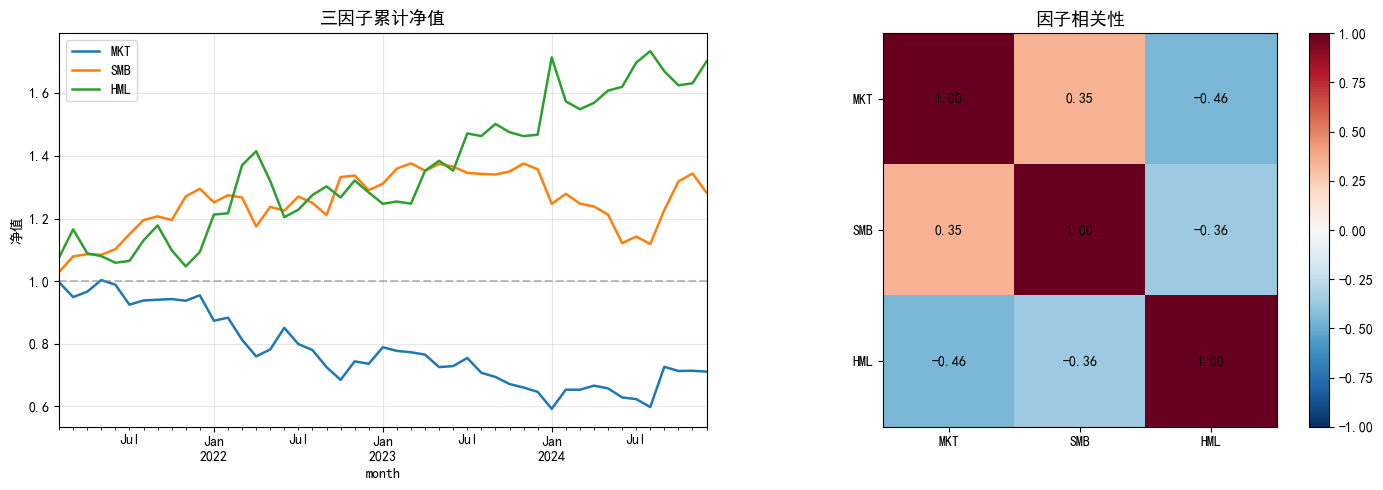

In [4]:
# ===================== Part 3：三因子表现与显著性 =====================
factors = ['MKT', 'SMB', 'HML']

# 月度均值显著性 t 检验（H0: 因子月均收益=0）
print('=== 因子月均收益 t 检验 ===')
summary = []
for f in factors:
    x = ff[f].dropna()
    t_stat = x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
    summary.append(dict(因子=f, 月均=x.mean(), 年化=x.mean() * 12,
                        年化波动=x.std(ddof=1) * np.sqrt(12), t值=t_stat))
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# 因子累计净值
nav = (1 + ff[factors]).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nav.plot(ax=axes[0], linewidth=1.8)
axes[0].set_title('三因子累计净值', fontsize=13)
axes[0].axhline(1, color='gray', ls='--', alpha=0.5)
axes[0].set_ylabel('净值'); axes[0].grid(True, alpha=0.3); axes[0].legend()

# 因子相关性热图
corr = ff[factors].corr()
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(factors)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(factors)
for r in range(3):
    for c in range(3):
        axes[1].text(c, r, f'{corr.iloc[r, c]:.2f}', ha='center', va='center')
axes[1].set_title('因子相关性', fontsize=13)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

=== 6 组合：CAPM vs FF3 回归（alpha 已年化）===
组合  CAPM_alpha  CAPM_R2  FF3_alpha  FF3_R2  FF3_t_alpha  b_MKT  b_SMB  b_HML
SL       0.109    0.727      0.058   0.974        2.335  0.878  0.940 -0.269
SM       0.159    0.773      0.098   0.943        3.377  0.829  0.711 -0.016
SH       0.156    0.631     -0.000   0.977       -0.016  1.081  0.768  0.718
BL      -0.045    0.884      0.032   0.973        1.563  1.024 -0.340 -0.386
BM       0.049    0.844      0.033   0.884        1.000  0.943 -0.073  0.191
BH       0.151    0.393      0.090   0.929        4.033  0.821 -0.168  0.628

平均 |alpha|：CAPM=0.1116, FF3=0.0517
平均 R^2：CAPM=0.7084, FF3=0.9466
解读：FF3 的平均 |alpha| 更小、R^2 更高，说明 SMB/HML 捕捉了 CAPM 漏掉的系统性风险。


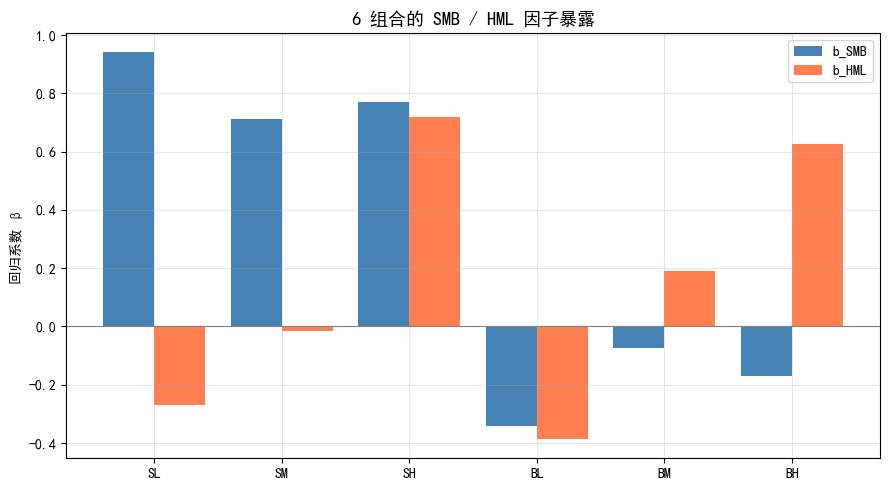

In [5]:
# ===================== Part 4：时序回归（FF3 vs CAPM 解释力对比） =====================
# 测试资产：6 个 2×3 组合的超额收益。分别用 CAPM(仅 MKT) 与 FF3(MKT+SMB+HML) 回归，
# 比较 α 是否更接近 0、R^2 是否提升。
test_assets = ['SL', 'SM', 'SH', 'BL', 'BM', 'BH']
rows = []
for a in test_assets:
    y = (ff[a] - rf_monthly).dropna()
    idx_common = y.index
    X1 = sm.add_constant(ff.loc[idx_common, ['MKT']])
    m1 = sm.OLS(y, X1).fit()
    X3 = sm.add_constant(ff.loc[idx_common, ['MKT', 'SMB', 'HML']])
    m3 = sm.OLS(y, X3).fit()
    rows.append(dict(
        组合=a,
        CAPM_alpha=m1.params['const'] * 12, CAPM_R2=m1.rsquared,
        FF3_alpha=m3.params['const'] * 12, FF3_R2=m3.rsquared,
        FF3_t_alpha=m3.tvalues['const'],
        b_MKT=m3.params['MKT'], b_SMB=m3.params['SMB'], b_HML=m3.params['HML'],
    ))
reg = pd.DataFrame(rows)
print('=== 6 组合：CAPM vs FF3 回归（alpha 已年化）===')
print(reg.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

print(f'\n平均 |alpha|：CAPM={reg["CAPM_alpha"].abs().mean():.4f}, FF3={reg["FF3_alpha"].abs().mean():.4f}')
print(f'平均 R^2：CAPM={reg["CAPM_R2"].mean():.4f}, FF3={reg["FF3_R2"].mean():.4f}')
print('解读：FF3 的平均 |alpha| 更小、R^2 更高，说明 SMB/HML 捕捉了 CAPM 漏掉的系统性风险。')

# 因子暴露符号检查：小盘组合 b_SMB 应更大，高BP组合 b_HML 应更大
fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(test_assets))
ax.bar(xpos - 0.2, reg['b_SMB'], width=0.4, label='b_SMB', color='steelblue')
ax.bar(xpos + 0.2, reg['b_HML'], width=0.4, label='b_HML', color='coral')
ax.set_xticks(xpos); ax.set_xticklabels(test_assets)
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('6 组合的 SMB / HML 因子暴露', fontsize=13)
ax.set_ylabel('回归系数 β'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# ===================== Part 5：GRS 联合检验 =====================
# 时序回归只能逐个看 α；GRS (Gibbons-Ross-Shanken, 1989) 检验所有测试资产的 α 是否【联合】为 0。
# 统计量： GRS = (T-N-K)/N · (a'Σ⁻¹a)/(1 + f̄'Ω⁻¹f̄)  ~  F(N, T-N-K)
#   T=期数, N=测试资产数, K=因子数, a=N×1 截距向量, Σ=残差协方差(÷T), f̄=因子均值, Ω=因子协方差(÷T)
# p 值越大越好：越不能拒绝"模型把所有 α 都解释为 0"，说明模型越完整。
from scipy import stats


def grs_test(excess_assets, factors):
    F = factors.values
    T, K = F.shape
    N = excess_assets.shape[1]
    Xc = sm.add_constant(F)
    alphas, resid = [], []
    for c in excess_assets.columns:
        m = sm.OLS(excess_assets[c].values, Xc).fit()
        alphas.append(m.params[0]); resid.append(m.resid)
    a = np.array(alphas)
    E = np.column_stack(resid)
    Sigma = E.T @ E / T                      # 残差协方差（最大似然估计）
    fbar = F.mean(axis=0)
    Fd = F - fbar
    Omega = np.atleast_2d(Fd.T @ Fd / T)     # 因子协方差
    sh2_f = float(fbar @ np.linalg.inv(Omega) @ fbar)   # 因子组合夏普比平方
    grs = (T - N - K) / N * float(a @ np.linalg.inv(Sigma) @ a) / (1 + sh2_f)
    p = stats.f.sf(grs, N, T - N - K)
    return grs, p, N, K, len(F)


ex6 = (ff[test_assets] - rf_monthly).dropna()
g_capm = grs_test(ex6, ff.loc[ex6.index, ['MKT']])
g_ff3 = grs_test(ex6, ff.loc[ex6.index, ['MKT', 'SMB', 'HML']])
print(f'测试资产 N={g_ff3[2]}  样本期 T={g_ff3[4]}')
print('=== GRS 联合检验（H0: 6 组合的 α 全为 0）===')
for name, g in [('CAPM', g_capm), ('FF3 ', g_ff3)]:
    verdict = '拒绝 H0（模型不完整，仍有未解释的 α）' if g[1] < 0.05 else '不拒绝 H0（模型已较好解释）'
    print(f'{name}: GRS={g[0]:.3f}, p={g[1]:.4f}  ->  {verdict}')
print('\n解读：p 值越大越好。FF3 的 p 通常高于 CAPM，说明加入 SMB/HML 后联合定价误差更小。')

测试资产 N=6  样本期 T=47
=== GRS 联合检验（H0: 6 组合的 α 全为 0）===
CAPM: GRS=6.185, p=0.0001  ->  拒绝 H0（模型不完整，仍有未解释的 α）
FF3 : GRS=4.455, p=0.0017  ->  拒绝 H0（模型不完整，仍有未解释的 α）

解读：p 值越大越好。FF3 的 p 通常高于 CAPM，说明加入 SMB/HML 后联合定价误差更小。


## 四、学习小结

1. **因子构建（Part 2）**：2×3 独立排序得到 6 个市值加权组合；$SMB$ 做多小盘做空大盘，$HML$ 做多高账面市值比（价值股）做空低账面市值比（成长股）。
2. **因子表现（Part 3）**：观察 SMB/HML 的年化收益与 t 值是否显著、三因子之间相关性是否较低（低相关说明因子互补）。
3. **解释力（Part 4）**：相比 CAPM，FF3 通常使各测试组合的 α 更接近 0、$R^2$ 更高；小盘组合对 $SMB$ 暴露更大、价值组合对 $HML$ 暴露更大，符合因子构造逻辑。
4. **GRS 联合检验（Part 5）**：单看一个 α 是否为 0 不够，GRS 同时检验**全部** α 是否为 0，是评价因子模型"漏没漏因子"的标准工具；p 值越大说明模型越完整。
5. **与 CAPM 的联系**：CAPM 只承认市场风险定价；FF3 补充了规模与价值两类系统性风险溢价。

**下一步**：[fama_french5.ipynb](fama_french5.ipynb) 在三因子上加入盈利(RMW)与投资(CMA)，看价值因子 HML 是否变得冗余，并用 GRS 对比 FF3 / FF5。